In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


C:\Users\hercd\AppData\Local\Temp\ipykernel_8724\1683341686.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_8724\1209351260.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


# ARIMA Models

In [4]:
arima_models = auto_arima(data["humidity"], trace= True, suppress_warnings= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=23.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=148621.984, Time=0.36 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=148354.193, Time=0.43 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=148407.808, Time=1.71 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=148619.984, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=148006.741, Time=0.61 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=147897.449, Time=1.32 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=147888.067, Time=1.62 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=147854.616, Time=1.99 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=145976.754, Time=25.00 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=147881.439, Time=17.23 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=144848.989, Time=36.69 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=147576.477, Time=27.92 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=44.62 sec
 ARIMA(4,1,3)

# Split Data

In [3]:
x_train = data["humidity"][: -168]
x_test = data["humidity"][-168: ]
x_train.shape, x_test.shape

((21815,), (168,))

In [6]:
model = ARIMA(x_test, order = (5, 1, 2))
model_fit = model.fit()
model_fit.summary()

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               humidity   No. Observations:                  168
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -553.817
Date:                Sat, 20 Jul 2024   AIC                           1123.635
Time:                        10:28:13   BIC                           1148.579
Sample:                    06-28-2024   HQIC                          1133.759
                         - 07-04-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1925      0.069      2.808      0.005       0.058       0.327
ar.L2          1.0517      0.084     12.529      0.000       0.887       1.216
ar.L3         -0.2056      0.124     -1.662      0.097      -0.448       0.037
ar.L4         -0.1792      0.073     -2.448      0.014      -0.323      -0.036
ar.L5         -0.0647      0.115     -0.564      0.573      -0.290       0.160
ma.L1      -4.295e-05     13.981  -3.07e-06      1.000     -27.402      27.402
ma.L2         -1.0000      0.078    -12.767      0.000      -1.153      -0.846
sigma2        43.3633      0.321    134.908      0.000      42.733      43.993
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               298.58
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               3.01   Skew:                             1.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.78e+19. Standard errors may be unstable.
"""

In [7]:
start_0 = len(x_train)
end_0 = start_0 + len(x_test) - 1
predictions_0 = model_fit.predict(start= start_0, end= end_0, typ='levels')
predictions_0.index = x_test.index

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


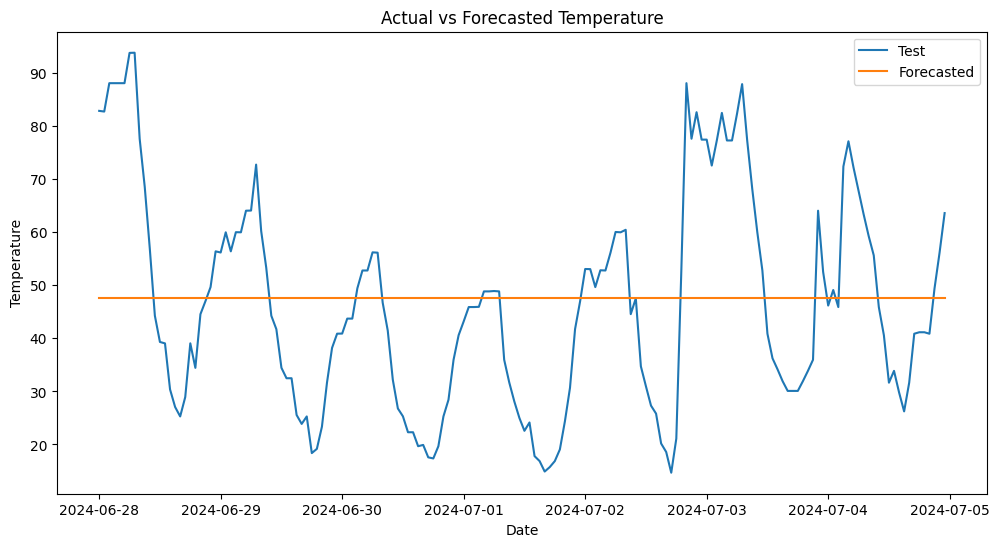

In [8]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions_0, label='Forecasted')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# SARIMA Model

In [9]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(x_train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -8.914786851202505
p-value: 1.0800322993567869e-14


### Από την στιγμή που έχουμε δεδομένα σε κάθε ώρα μέσα στην μέρα τότε το seasonality θα επαναλαμβάνεται κάθε 24 ώρες (points) 

In [5]:
model_sarima = SARIMAX(x_train, order=(5, 1, 2), seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                             humidity   No. Observations:                21815
Model:             SARIMAX(5, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -70137.912
Date:                              Sat, 20 Jul 2024   AIC                         140295.825
Time:                                      12:42:42   BIC                         140375.717
Sample:                                           0   HQIC                        140321.855
                                            - 21815                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1143      0.118     -0.966      0.334      -0.346       0.118
ar.L2          0.83

### seasonal_order(1, 1, 1, 24) $\rightarrow$ 99.7959999%
### seasonal_order(1, 1, 2, 24) $\rightarrow$ 99.7952591%
### seasonal_order(2, 1, 2, 24) $\rightarrow$ 99.7915105%


In [6]:
x_train.index = pd.to_datetime(x_train.index)
x_test.index = pd.to_datetime(x_test.index)

In [7]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test))
predictions = forecast.predicted_mean
predictions.index = x_test.index

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


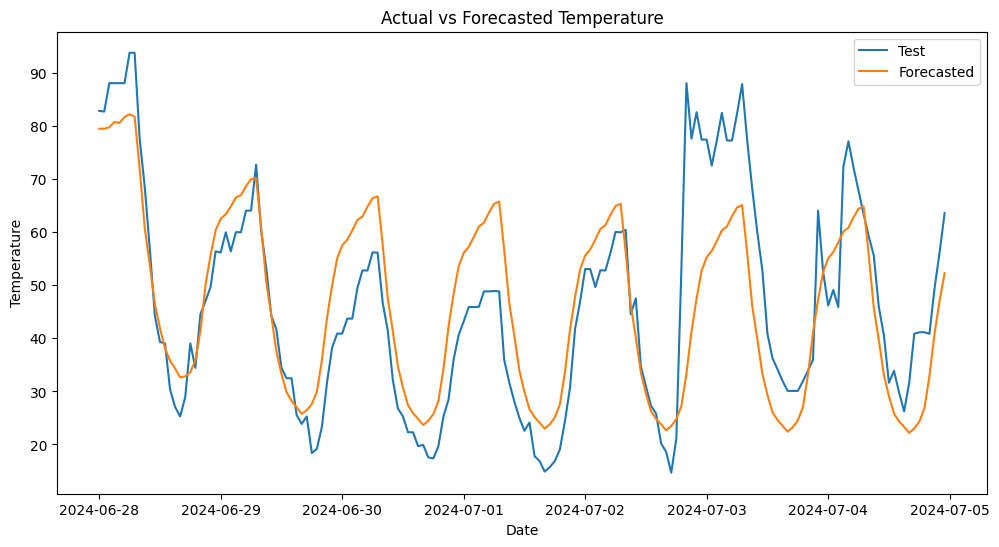

In [8]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions, label='Forecasted')
plt.title('Actual vs Forecasted Humidity')
plt.xlabel('Date')
plt.ylabel('Humid.')
plt.legend()
plt.show()

In [9]:
mse = mean_squared_error(x_test, predictions)
tss = ((x_test - x_test.mean()) ** 2).sum()
r_squared = 1 - (mse / tss)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 99.79587305999999% of total variability 
 Root Mean Squared Error =  11.734889149698922
